In [1]:
%pip list

Package                 Version
----------------------- -----------
aiodns                  3.6.1
aiohappyeyeballs        2.7.1
aiohttp                 3.14.3
aiosignal               1.4.0
annotated-doc           0.0.5
anyio                   4.14.2
asttokens               3.0.2
attrs                   26.1.0
brotlicffi              1.2.0.1
certifi                 2026.7.22
cffi                    2.1.1
charset-normalizer      3.5.1
click                   8.5.0
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
datasets                5.0.1
debugpy                 1.8.21
dill                    0.4.1
executing               2.2.1
filelock                3.32.4
fonttools               4.63.0
frozenlist              1.8.0
fsspec                  2026.6.0
h11                     0.16.0
hf-xet                  1.6.0
httpcore                1.0.9
httpx                   0.28.1
huggingface_hub         1.28.0
idna         

In [2]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading data

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# cuz this date column was type str, now changed to type datetime

d:\Program Files\Anaconda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.loc[:10, 'salary_year_avg':'salary_hour_avg']

,salary_year_avg,salary_hour_avg
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [4]:
# setting NaN values as median values for each column

median_ysalary = df['salary_year_avg'].median()
median_hsalary = df['salary_hour_avg'].median()

In [5]:
df_filled = df
df_filled['salary_year_avg'] = df_filled['salary_year_avg'].fillna(median_ysalary)
df_filled['salary_hour_avg'] = df_filled['salary_hour_avg'].fillna(median_hsalary)

In [6]:
df_filled.loc[:10, 'salary_year_avg': 'salary_hour_avg']

,salary_year_avg,salary_hour_avg
0,115000.0,45.98
1,115000.0,45.98
2,115000.0,45.98
3,115000.0,45.98
4,115000.0,45.98
5,115000.0,45.98
6,115000.0,45.98
7,115000.0,45.98
8,115000.0,45.98
9,115000.0,45.98


In [7]:
df_unique = df_filled

df_unique = df_unique.drop_duplicates()

print('Len of original values:' , len(df_filled))
print('Len of unique values:'   , len(df_unique))
print('Len of diff'             , len(df_filled) - len(df_unique))

Len of original values: 785741
Len of unique values: 785640
Len of diff 101


In [8]:
df_unique = df_unique.drop_duplicates(subset = ['job_title', 'job_title_short'])
df_unique
#  clears rows in which same pair of job_title_short and job_title available, only remains 1st common pair

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,115000.0,45.98,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,115000.0,45.98,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,115000.0,45.98,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,115000.0,45.98,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,115000.0,45.98,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785721,Business Analyst,IT Business Analyst Data,Jerman,melalui Indeed,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,115000.0,45.98,Raisin,"['sql', 'python', 'aws', 'looker', 'tableau', ...","{'analyst_tools': ['looker', 'tableau', 'splun..."
785722,Business Analyst,Business Analytics Training and Internship,Jerman,melalui LinkedIn,NaN,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,115000.0,45.98,OESON,['python'],{'programming': ['python']}
785734,Business Analyst,PreSales Engineer,"Almaty, Kazakhstan",melalui Melga,Pekerjaan tetap,False,Kazakhstan,2023-03-12 06:31:13,False,False,Kazakhstan,NaN,115000.0,45.98,Staff-UP Consulting Group,['windows'],{'os': ['windows']}
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,115000.0,45.98,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"


In [ ]:
df.sample(7)   # random sample for 7 rows

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
285572,Data Engineer,Data Engineer(Full time ),Anywhere,via Indeed,Full-time,True,"Florida, United States",2023-02-09 17:26:21,True,False,United States,NaN,115000.0,45.98,Integration Developer Network LLC,['sql'],{'programming': ['sql']}
374562,Data Engineer,Data Engineer,Anywhere,via Indeed,Full-time,True,Sudan,2023-06-02 19:15:35,False,True,Sudan,year,75000.0,45.98,CyberCoders,"['sql', 'python', 'snowflake', 'oracle', 'powe...","{'analyst_tools': ['power bi', 'tableau', 'sap..."
239093,Senior Data Engineer,Senior Data Engineer,"Auckland, New Zealand",via Indeed,Full-time,False,New Zealand,2023-02-17 07:51:51,True,False,New Zealand,NaN,115000.0,45.98,Absolute IT Recruitment Specialists,"['sql', 'python', 'mysql', 'snowflake', 'azure']","{'cloud': ['snowflake', 'azure'], 'databases':..."
31215,Data Analyst,Data Analist,"Rotterdam, Netherlands",via BeBee,Full-time and Part-time,False,Netherlands,2023-12-05 13:23:26,True,False,Netherlands,NaN,115000.0,45.98,CGI,NaN,NaN
620281,Data Scientist,Data Scientist (Remote Sensing),Abu Dhabi - United Arab Emirates,via LinkedIn,Full-time,False,United Arab Emirates,2023-06-01 13:26:27,False,False,United Arab Emirates,NaN,115000.0,45.98,Bayanat.AI,"['python', 'gcp', 'aws', 'azure']","{'cloud': ['gcp', 'aws', 'azure'], 'programmin..."
515694,Senior Data Scientist,Senior Data Scientist,"Brooklyn Park, MN",via The Muse,Full-time,False,"Illinois, United States",2023-02-01 11:23:25,False,False,United States,NaN,115000.0,45.98,Target,"['python', 'sql', 'r', 'sas', 'sas', 'mysql', ...","{'analyst_tools': ['sas'], 'databases': ['mysq..."
640082,Data Scientist,Data Integration Specialist,"Manchester, UK",via WREG Jobs,Full-time,False,United Kingdom,2023-07-11 12:22:22,False,False,United Kingdom,NaN,115000.0,45.98,Jobleads-UK,['sql'],{'programming': ['sql']}


In [10]:
df.sample(10, random_state = 41)   # random_state = any int value from 0

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
476634,Data Analyst,Data Analytics Developer | AD824,"Cali, Valle del Cauca, Colombia",via Kit Empleo,Full-time,False,Colombia,2023-01-03 23:48:28,False,False,Colombia,NaN,115000.0,45.98,Bairesdev,"['sql', 'python', 'sql server', 'tableau', 'ss...","{'analyst_tools': ['tableau', 'ssis'], 'databa..."
364748,Data Scientist,PhD position on data science with tensor decom...,Belgium,via Mendeley,Full-time,False,Belgium,2023-06-22 23:55:25,False,False,Belgium,NaN,115000.0,45.98,KU Leuven,"['matlab', 'python']","{'programming': ['matlab', 'python']}"
744884,Software Engineer,Senior Software Engineer,Philippines,via Trabajo.org,Full-time,False,Philippines,2023-02-19 20:14:08,True,False,Philippines,NaN,115000.0,45.98,Appen,"['c', 'python', 'java', 'shell', 'groovy', 'po...","{'cloud': ['aws', 'redshift', 'gcp'], 'databas..."
599937,Data Analyst,Functional Data Analyst - Investment,"Brussels, Belgium",via Indeed,Contractor,False,Belgium,2023-11-28 09:35:41,False,False,Belgium,NaN,115000.0,45.98,Oliver James Associates,"['python', 'r', 'sql']","{'programming': ['python', 'r', 'sql']}"
265529,Business Analyst,BI Analyst,"Dublin, Ireland",via BeBee Ireland,Full-time,False,Ireland,2023-01-05 07:50:12,True,False,Ireland,NaN,115000.0,45.98,search talent people limited,"['sql', 'python', 'r', 'tableau', 'power bi']","{'analyst_tools': ['tableau', 'power bi'], 'pr..."
219602,Business Analyst,BI Business Analytics and Process Engineer - R...,"San Juan, Puerto Rico",via Whatjobs? Jobs In The PuertoRico,Full-time,False,Puerto Rico,2023-10-25 23:38:31,False,False,Puerto Rico,NaN,115000.0,45.98,"Ryder System, Inc","['sql', 'microstrategy', 'power bi', 'tableau'...","{'analyst_tools': ['microstrategy', 'power bi'..."
770385,Data Analyst,Data Analyst,"Philadelphia, PA",via Indeed,Full-time,False,"New York, United States",2023-01-26 01:00:09,False,True,United States,year,56212.5,45.98,CORA Services,"['sql', 'tableau', 'power bi', 'excel', 'word']","{'analyst_tools': ['tableau', 'power bi', 'exc..."
286495,Data Engineer,Data Engineer on W2,"Dallas, TX",via LinkedIn,Contractor,False,"New York, United States",2023-12-04 17:05:35,False,False,United States,NaN,115000.0,45.98,AALPHA PRIME TECH GLOBAL,"['python', 'shell', 'java', 'sql', 'bigquery',...","{'cloud': ['bigquery', 'azure', 'databricks', ..."
452968,Data Engineer,Data Engineer II,"Remote, OR",via SmartRecruiters Job Search,Full-time,False,"California, United States",2023-03-29 14:28:27,True,False,United States,NaN,115000.0,45.98,insightsoftware,"['python', 'sql', 'sql server', 'aws', 'azure'...","{'analyst_tools': ['ssis'], 'cloud': ['aws', '..."
390803,Data Scientist,Data Scientist-Business Intelligence Engineer ...,"Richmond, VA",via WANE Jobs,Full-time,False,Georgia,2023-05-20 18:08:30,False,False,United States,NaN,115000.0,45.98,Wolters Kluwer,"['r', 'python', 'sql', 'aws', 'redshift', 'tab...","{'analyst_tools': ['tableau', 'power bi', 'qli..."


In [11]:
df_original = df
df_altered = df_original.copy()

In [12]:
print('ID original:' , id(df_original))
print('ID altered:'  , id(df_altered))
print('Same?:'       , id(df_altered) == id(df_original))

ID original: 2892409540336
ID altered: 2892409550032
Same?: False


In [13]:
###  PIVOT  ###

In [14]:
df.pivot_table(index = 'job_title_short', aggfunc= 'size')   
# size - all values; count - non null values

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [15]:
df.groupby('job_title_short').size()  # same above

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [16]:
df.pivot_table(index = 'job_title_short', values = 'salary_year_avg', aggfunc = 'median')

,salary_year_avg
job_title_short,
Business Analyst,115000.0
Cloud Engineer,115000.0
Data Analyst,115000.0
Data Engineer,115000.0
Data Scientist,115000.0
Machine Learning Engineer,115000.0
Senior Data Analyst,115000.0
Senior Data Engineer,115000.0
Senior Data Scientist,115000.0


In [17]:
df.groupby('job_title_short')['salary_year_avg'].median()   # same above

job_title_short
Business Analyst             115000.0
Cloud Engineer               115000.0
Data Analyst                 115000.0
Data Engineer                115000.0
Data Scientist               115000.0
Machine Learning Engineer    115000.0
Senior Data Analyst          115000.0
Senior Data Engineer         115000.0
Senior Data Scientist        115000.0
Software Engineer            115000.0
Name: salary_year_avg, dtype: float64

In [18]:
df.pivot_table(index = 'job_country', columns = "job_title_short", values = 'salary_year_avg', aggfunc = 'median')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Afghanistan,115000.0,NaN,115000.0,NaN,115000.0,NaN,115000.0,NaN,NaN,NaN
Albania,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Algeria,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,NaN,115000.0,NaN,115000.0
Angola,115000.0,NaN,115000.0,115000.0,115000.0,NaN,NaN,NaN,115000.0,115000.0
Argentina,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
...,...,...,...,...,...,...,...,...,...,...
Venezuela,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Vietnam,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Yemen,115000.0,NaN,115000.0,115000.0,NaN,NaN,NaN,NaN,NaN,115000.0


In [19]:
top_countries = df['job_country'].value_counts().head(6).index
top_countries

Index(['United States', 'India', 'United Kingdom', 'France', 'Germany',
       'Spain'],
      dtype='str', name='job_country')

In [20]:
df_job_country_salary = df.pivot_table(index = 'job_country', columns = "job_title_short", values = 'salary_year_avg', aggfunc = 'median')
df_job_country_salary 

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Afghanistan,115000.0,NaN,115000.0,NaN,115000.0,NaN,115000.0,NaN,NaN,NaN
Albania,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Algeria,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,NaN,115000.0,NaN,115000.0
Angola,115000.0,NaN,115000.0,115000.0,115000.0,NaN,NaN,NaN,115000.0,115000.0
Argentina,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
...,...,...,...,...,...,...,...,...,...,...
Venezuela,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Vietnam,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Yemen,115000.0,NaN,115000.0,115000.0,NaN,NaN,NaN,NaN,NaN,115000.0


In [21]:
df_job_country_salary = df_job_country_salary.loc[top_countries]
df_job_country_salary 

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
United States,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
India,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
United Kingdom,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
France,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Germany,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0
Spain,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0,115000.0


In [22]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']


In [23]:
df_job_country_salary = df_job_country_salary[job_titles]
df_job_country_salary 

job_title_short,Data Analyst,Data Engineer,Data Scientist
job_country,,,
United States,115000.0,115000.0,115000.0
India,115000.0,115000.0,115000.0
United Kingdom,115000.0,115000.0,115000.0
France,115000.0,115000.0,115000.0
Germany,115000.0,115000.0,115000.0
Spain,115000.0,115000.0,115000.0


Text(0.5, 1.0, 'Salaries in top countries')

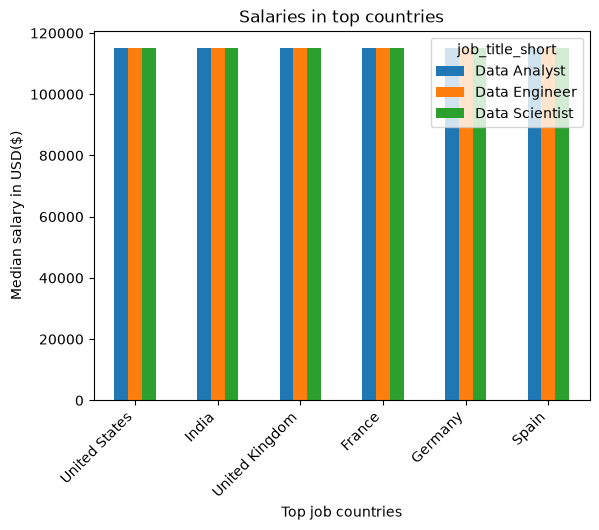

In [24]:
df_job_country_salary.plot(kind='bar')
plt.xlabel('Top job countries')
plt.ylabel('Median salary in USD($)')
plt.xticks(rotation=45, ha='right')
plt.title('Salaries in top countries')

In [25]:
df.index

RangeIndex(start=0, stop=785741, step=1)

In [26]:
df.index.name = 'job_index'

In [ ]:
df

In [28]:
df.index.dtype

dtype('int64')

In [ ]:
df_us = df[df['job_country'] == 'United States']
df_us

In [ ]:
df_us.reset_index()

In [ ]:
df_us

In [ ]:
df_us.reset_index(inplace = True)
df_us

In [33]:
df_us.set_index('job_index', inplace = True)

In [ ]:
df_us

In [41]:
median_pivot = df_us.pivot_table(index= 'job_title_short', values = 'salary_year_avg', aggfunc = ['mean', 'median'])

In [42]:
median_pivot

,mean,median
,salary_year_avg,salary_year_avg
job_title_short,,
Business Analyst,113900.923575,115000.0
Cloud Engineer,115240.704492,115000.0
Data Analyst,113688.506362,115000.0
Data Engineer,116597.655722,115000.0
Data Scientist,116930.687709,115000.0
Machine Learning Engineer,120453.603692,115000.0
Senior Data Analyst,115056.457947,115000.0
Senior Data Engineer,119151.362744,115000.0


In [44]:
median_pivot.sort_values(by= ('median', 'salary_year_avg'), ascending = False)

,mean,median
,salary_year_avg,salary_year_avg
job_title_short,,
Business Analyst,113900.923575,115000.0
Cloud Engineer,115240.704492,115000.0
Data Analyst,113688.506362,115000.0
Data Engineer,116597.655722,115000.0
Data Scientist,116930.687709,115000.0
Machine Learning Engineer,120453.603692,115000.0
Senior Data Analyst,115056.457947,115000.0
Senior Data Engineer,119151.362744,115000.0


In [45]:
median_pivot.sort_index()

,mean,median
,salary_year_avg,salary_year_avg
job_title_short,,
Business Analyst,113900.923575,115000.0
Cloud Engineer,115240.704492,115000.0
Data Analyst,113688.506362,115000.0
Data Engineer,116597.655722,115000.0
Data Scientist,116930.687709,115000.0
Machine Learning Engineer,120453.603692,115000.0
Senior Data Analyst,115056.457947,115000.0
Senior Data Engineer,119151.362744,115000.0


In [ ]:
median_pivot.sort_index(inplace = True)
# sort_index() used when index column has no name

In [48]:
median_pivot.sort_values(by= 'job_title_short', ascending = False)   
# same above 

,mean,median
,salary_year_avg,salary_year_avg
job_title_short,,
Software Engineer,116987.593134,115000.0
Senior Data Scientist,119249.503024,115000.0
Senior Data Engineer,119151.362744,115000.0
Senior Data Analyst,115056.457947,115000.0
Machine Learning Engineer,120453.603692,115000.0
Data Scientist,116930.687709,115000.0
Data Engineer,116597.655722,115000.0
Data Analyst,113688.506362,115000.0
